Feature dataset preview:


,Open,High,Low,Close,Volume,RV_daily_sq,RV_21,Parkinson_21,log_ret,RV_target,...,parkinson,garman_klass,regime_high_vol,vol_spike,ret_spike,VIX_level,VIX_change,vol_of_vol,GARCH_vol_forecast,HAR_RV_forecast
Date,,,,,,,,,,,,,,,,,,,,,
2023-04-26,18.660000,19.610001,17.870001,18.840000,0,0.000018,0.163710,0.200321,0.004255,0.163710,...,0.003114,0.004281,0,0,0,18.840000,0.004264,-0.049803,0.075682,0.000918
2023-04-27,18.430000,18.430000,16.719999,17.030001,0,0.010202,0.189838,0.204132,-0.101006,0.189838,...,0.003420,0.002330,0,0,1,17.030001,-0.096072,0.159598,0.068660,0.000768
2023-04-28,17.209999,17.650000,15.720000,15.780000,0,0.005812,0.199895,0.215362,-0.076233,0.199895,...,0.004837,0.003798,0,0,1,15.780000,-0.073400,0.052977,0.077984,0.001116
2023-05-01,16.410000,16.620001,15.530000,16.080000,0,0.000355,0.200712,0.215868,0.018833,0.200712,...,0.001660,0.002141,0,0,0,16.080000,0.019011,0.004086,0.077764,0.001217
2023-05-02,16.270000,19.809999,16.260000,17.780001,0,0.010100,0.223824,0.244611,0.100498,0.223824,...,0.014065,0.016456,0,0,1,17.780001,0.105721,0.115151,0.070892,0.001135



Number of features: 61  (excluding target)
Train size: 515, Test size: 129
LSTM train sequence shape: (494, 21, 61)
LSTM test sequence shape: (108, 21, 61)
Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_2 (LSTM)               (None, 64)                32256     
                                                                 
 dense_4 (Dense)             (None, 32)                2080      
                                                                 
 dense_5 (Dense)             (None, 1)                 33        
                                                                 
Total params: 34369 (134.25 KB)
Trainable params: 34369 (134.25 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/25
14/14 [==============================] - 2s 40ms/step - loss: 0.0870 - val_loss: 0.0692
Epoch 2/25
14/14 [======

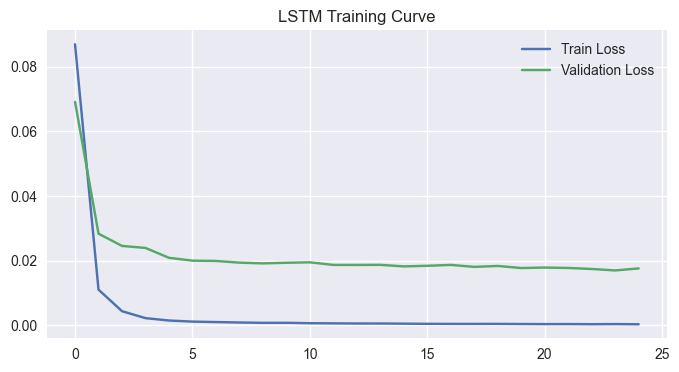

4/4 [==============================] - 0s 4ms/step


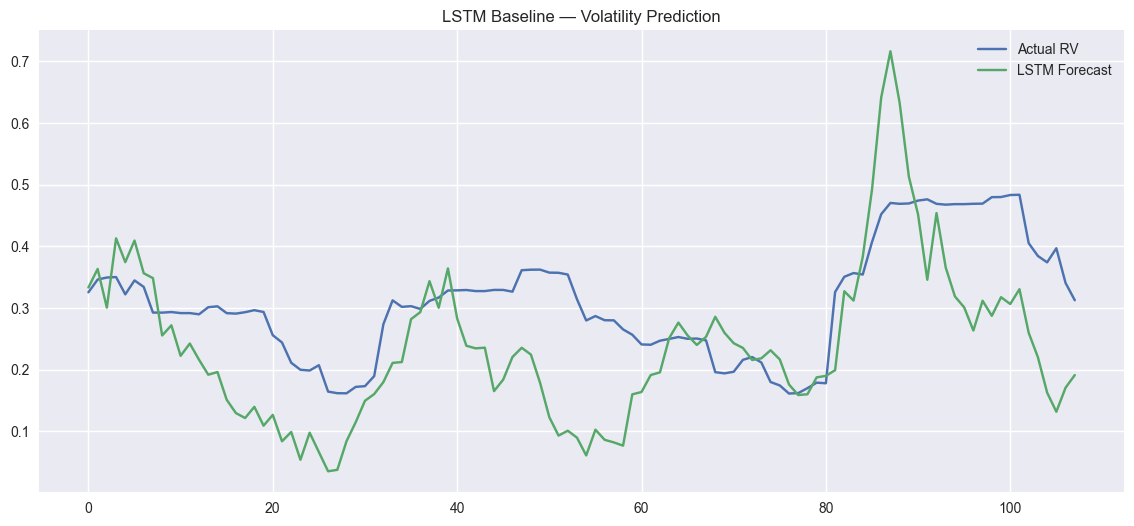

LSTM Forecast Performance:
MSE: 0.015020
MAE: 0.099517

Saved LSTM forecasts to: ../data/processed/lstm_forecasts.csv


In [4]:
# ===========================================
# Notebook 06 — LSTM Baseline for Volatility
# ===========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import os

plt.style.use("seaborn-v0_8")

# Load Feature Matrix
df = pd.read_csv("../data/processed/features.csv", parse_dates=["Date"])
df = df.set_index("Date")

print("Feature dataset preview:")
display(df.head())

print("\nNumber of features:", df.shape[1] - 1, " (excluding target)")

# Define Target + Features
TARGET = "RV_target"

X = df.drop(columns=[TARGET])
y = df[TARGET]

feature_names = X.columns.tolist()

# Train/Test Split (80% training - 20% testing)
split_idx = int(len(df) * 0.80)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

# Scale Inputs
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


# 5. Prepare Sequence Data
# LSTM expects: batch, timesteps, features
# Use a 21-day input window to predict RV(t+1)
SEQ_LEN = 21

def make_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(seq_len, len(X)):
        Xs.append(X[i - seq_len:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

X_train_seq, y_train_seq = make_sequences(X_train_scaled, y_train.values, SEQ_LEN)
X_test_seq,  y_test_seq  = make_sequences(X_test_scaled,  y_test.values,  SEQ_LEN)

print("LSTM train sequence shape:", X_train_seq.shape)
print("LSTM test sequence shape:", X_test_seq.shape)

# Build LSTM Model
lstm_model = models.Sequential([
    layers.Input(shape=(SEQ_LEN, X_train_seq.shape[2])),
    layers.LSTM(64, return_sequences=False),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)
])

lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse"
)

lstm_model.summary()

# Train Model
history = lstm_model.fit(
    X_train_seq, y_train_seq,
    validation_split=0.1,
    epochs=25,
    batch_size=32,
    verbose=1
)

# Plot training history
'''
The training loss drops very fast and becomes almost zero,
 which means the LSTM learns the in-sample patterns easily. 
 The validation loss stays higher and mostly flat.
This tells us that the model is not overfitting, 
but it also isnt improving much after the first few epochs. 

Overall, it learns the general structure, but the real volatility data is still harder to predict.
'''
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.title("LSTM Training Curve")
plt.legend()
plt.show()


# Make Predictions
y_pred = lstm_model.predict(X_test_seq).flatten()

# Plot training history
'''
The LSTM forecast follows the general trend of volatility, but its much smoother than the real RV. 
It tends to miss sudden jumps and big spikes, and sometimes it predicts too high during calm periods.

Overall, this is normal for a simple LSTM. 
It captures slow changes but struggles with fast volatility shocks, especially in VIX-type data.
'''
plt.figure(figsize=(14, 6))
plt.plot(y_test_seq := y_test_seq if 'y_test_seq' in locals() else y_test_seq, label="Actual RV")
plt.plot(y_pred, label="LSTM Forecast")
plt.title("LSTM Baseline — Volatility Prediction")
plt.legend()
plt.show()

# Forecast Evaluation
mse = mean_squared_error(y_test_seq, y_pred)
mae = mean_absolute_error(y_test_seq, y_pred)

print("LSTM Forecast Performance:")
print(f"MSE: {mse:.6f}")
print(f"MAE: {mae:.6f}")

# Save Outputs
os.makedirs("../data/processed", exist_ok=True)
out_path = "../data/processed/lstm_forecasts.csv"
pd.DataFrame({
    "Actual_RV": y_test_seq,
    "LSTM_Forecast": y_pred
}, index=y_test.index[-len(y_test_seq):]).to_csv(out_path)
print("\nSaved LSTM forecasts to:", out_path)